# Mini-pipeline d’analyse (intro)

## Question de départ
**Comment analyser des données réelles sans se perdre dans le code ni les outils ?**

On va suivre un mini-pipeline :
1. **Charger** des données
2. **Regarder** (inspection rapide)
3. **Nettoyer** (valeurs manquantes / types)
4. **Transformer** (features simples)
5. **Analyser** (statistiques + visualisation)

> Objectif : voir le processus “en vrai”.

## 0) Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
np.random.seed(42)

## 1) Charger un premier jeu de données

On utilise un dataset **local** fourni par `scikit-learn` (pas besoin d’Internet).

In [2]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
df = iris.frame.copy()
df.rename(columns={"target": "species"}, inplace=True)
df["species"] = df["species"].map(dict(enumerate(iris.target_names)))

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2) Regarder les données (inspection)

On veut répondre à des questions simples :
- Quelles colonnes ?
- Quelles valeurs manquantes ?
- Quels ordres de grandeur ?

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df.describe(include='all')

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.057333,3.758000,1.199333,NaN
std,0.828066,0.435866,1.765298,0.762238,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


## 3) (Simuler) un problème réaliste : valeurs manquantes

Pour illustrer le nettoyage, on introduit volontairement quelques NaN.

In [5]:
df_dirty = df.copy()

# Introduire ~5% de valeurs manquantes dans deux colonnes
mask1 = np.random.rand(len(df_dirty)) < 0.05
mask2 = np.random.rand(len(df_dirty)) < 0.05

df_dirty.loc[mask1, "sepal length (cm)"] = np.nan
df_dirty.loc[mask2, "petal width (cm)"] = np.nan

df_dirty.isna().mean().sort_values(ascending=False)

sepal length (cm)    0.06
petal width (cm)     0.06
sepal width (cm)     0.00
petal length (cm)    0.00
species              0.00
dtype: float64

## 4) Nettoyage

Ici, stratégie simple : **imputation par médiane** (sur les colonnes numériques).

In [6]:
df_clean = df_dirty.copy()

num_cols = df_clean.select_dtypes(include=["number"]).columns
for c in num_cols:
    df_clean[c] = df_clean[c].fillna(df_clean[c].median())

df_clean.isna().sum()

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

## 5) Transformation (feature engineering léger)

On crée 2 variables simples :
- ratio pétale/sepale
- surface approx. pétale (longueur × largeur)

L’idée : **transformations cohérentes** au service d’une question.

In [7]:
df_feat = df_clean.copy()

df_feat["petal_area"] = df_feat["petal length (cm)"] * df_feat["petal width (cm)"]
df_feat["petal_to_sepal_ratio"] = df_feat["petal length (cm)"] / df_feat["sepal length (cm)"]

df_feat.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,petal_area,petal_to_sepal_ratio
0,5.1,3.5,1.4,0.2,setosa,0.28,0.274510
1,4.9,3.0,1.4,0.2,setosa,0.28,0.285714
2,4.7,3.2,1.3,0.2,setosa,0.26,0.276596
3,4.6,3.1,1.5,0.2,setosa,0.30,0.326087
4,5.0,3.6,1.4,0.2,setosa,0.28,0.280000


## 6) Analyse

Exemple de question (simple) :
> **Quelles variables distinguent le mieux les espèces ?**

On commence par une analyse descriptive : moyennes par espèce.

In [8]:
summary = df_feat.groupby("species").mean(numeric_only=True)
summary

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),petal_area,petal_to_sepal_ratio
species,,,,,,
setosa,5.064,3.428,1.462,0.284,0.4266,0.289655
versicolor,5.924,2.770,4.260,1.326,5.7204,0.719572
virginica,6.548,2.974,5.552,1.964,10.9490,0.849610


### Visualisation rapide
Un graphique simple pour rendre visible une séparation.

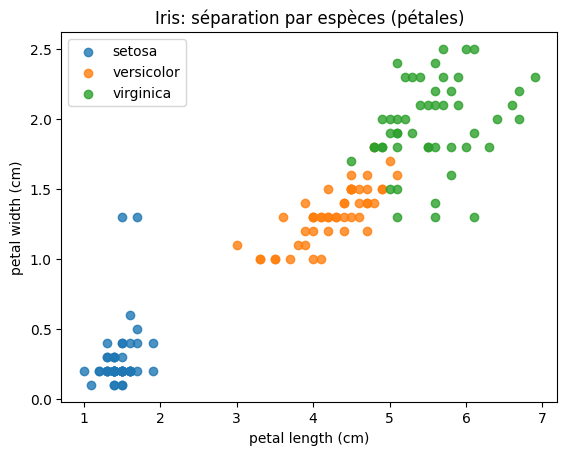

In [9]:
plt.figure()
for sp, g in df_feat.groupby("species"):
    plt.scatter(g["petal length (cm)"], g["petal width (cm)"], label=sp, alpha=0.8)
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()
plt.title("Iris: séparation par espèces (pétales)")
plt.show()

## 7) Récap pipeline (ce qu’on a fait)

- **Données** : iris
- **Nettoyage** : NaN → médiane
- **Transformation** : `petal_area`, `petal_to_sepal_ratio`
- **Analyse** : stats par groupe + scatter plot

### Phrase à retenir
> **Le plus important n’est pas l’outil, mais la question que le pipeline sert.**

## (Option) Exercice minute
1. Propose une **nouvelle question** sur ces données.
2. Dis quelles **transformations** seraient nécessaires.
3. Quelle **visualisation** ferait sens ?